# Multi-Asset Momentum ETF Strategy
### A Risk-Controlled Drawdown-Reduction Experiment · Paper Execution via Alpaca Markets

---

> **Research framing:** This is a **learning and research project**, not a finished trading system. The strategy deliberately trades absolute return for capital protection — it underperforms SPY on raw CAGR but reduces maximum drawdown by ~45%. The core question is: *what does that protection cost, and is the trade-off worth it?*

This notebook implements a systematic, rules-based momentum strategy across five liquid ETFs. The signal engine uses `gs_quant.alpaca.portfolio` — a **custom module** built within this repository that applies GS Quant-style signal architecture to Alpaca Markets paper execution. Mathematical implementations mirror `gs_quant.timeseries` algorithms, written from first principles.

| Layer | Contents |
|-------|----------|
| **Mathematics** | Formulas from first principles, mirroring `gs_quant.timeseries` |
| **Signals** | Trend/momentum engine via the custom `gs_quant.alpaca.portfolio` module |
| **Risk** | 12+ quant ratios, VaR/CVaR, Hurst exponent, walk-forward validation, sensitivity analysis |
| **Execution** | Paper trading via Alpaca Markets API |

---
## Research Memo

**Title:** A 20-Year Momentum ETF Strategy: Risk-Adjusted Returns Across Two Full Market Cycles

---

### Hypothesis
A systematic trend-following and momentum filter applied to a diversified multi-asset ETF universe can meaningfully reduce portfolio drawdown during bear markets, even if it sacrifices some absolute return in sustained bull markets. The core claim is that risk-adjusted returns — Sharpe, Sortino, and Calmar — are the more honest performance measure for a long-term investor who cannot tolerate large losses.

---

### Why These Five ETFs? (Universe Selection Rationale)

The universe was selected **before examining any backtest results**, based entirely on structural characteristics:

| ETF | Asset Class | Inception | Reason for Inclusion |
|-----|------------|-----------|----------------------|
| SPY | US Large-Cap Equity | Jan 1993 | Core equity exposure, most liquid ETF in the world |
| QQQ | US Growth/Tech Equity | Mar 1999 | High-beta equity; captures tech cycle |
| IWM | US Small-Cap Equity | May 2000 | Low-correlation equity factor; size premium |
| TLT | Long-Duration Treasury | Jul 2002 | Flight-to-safety asset; historically negative equity beta |
| GLD | Gold | Nov 2004 | Inflation hedge; uncorrelated to both equity and bonds |

**GLD launched November 2004**, making 2005-01-01 the earliest clean start date for the full universe. This means the universe and start date were constrained by data availability — not selected to optimise performance. No ETF in the universe was chosen because it performed well in the test period.

**Look-ahead bias addressed:** The only decision that could introduce look-ahead bias at the universe design stage would be selecting ETFs that survived and became prominent. All five are benchmark-tracking, low-cost index ETFs with effectively zero manager alpha — survivorship bias is minimal compared to single-stock or active-manager universes.

---

### Backtest Period: 20 Years Across Two Full Market Cycles (2005–2024)

| Period | Market Regime | Strategy Expectation |
|--------|--------------|----------------------|
| 2005–2007 | Late bull market | Follow momentum; moderate gains |
| 2008–2009 | Global Financial Crisis | Trend filter exits equities; cash escape tested |
| 2010–2019 | Long bull market | Under-hedged exposure; likely underperforms SPY |
| 2020 Q1 | COVID crash | Fast exit on trend break |
| 2020 Q2–Q4 | V-shaped recovery | Potential miss on rapid recovery |
| 2022 | Inflation / rate shock | Equities AND bonds fall; limits diversification benefit |
| 2023–2024 | AI-led tech recovery | QQQ dominates; strategy holds but with lag |

Two full bear markets (2008 and 2022) are included. A strategy that *only* worked in the 2019-2024 window would be suspect — this tests it across the full regime cycle.

---

### Why the Strategy May Underperform SPY in Bull Markets
The trend filter's cash-escape mechanism is a *bear market tool*. In sustained uptrends with only brief drawdowns (2010–2019, 2020 recovery), the cost of caution compounds. This is not a flaw; it is the fundamental Sharpe/CAGR trade-off of trend following. The right benchmark for a multi-asset strategy is not SPY — it is the 60/40 portfolio.

---

### Transaction Cost Assumption
**10 bps per trade** is used throughout. This is already an optimistic assumption:
- Liquid ETF bid/ask spreads: ~1–2 bps under normal conditions
- Market impact during rebalancing (end-of-month): 3–8 bps
- Stressed market conditions (e.g., March 2020): can reach 20–50 bps

The Limitations section includes a transaction cost sensitivity table at 5, 10, and 25 bps.

---

### Future Work
1. Extend parameter search with a proper genetic algorithm or Bayesian optimisation
2. Add carry and value signals alongside momentum
3. Test broader universe (sector ETFs, international)
4. Replace fixed parameters with regime-conditional signal weights
5. Bootstrap confidence intervals on the Sharpe ratio to separate skill from luck

## 1. Setup

In [25]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import scipy.stats as stats
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# gs_quant portfolio engine (works without full GS Marquee session)
from gs_quant.alpaca.portfolio import (
    PortfolioSettings, compute_signal_frame,
    target_weights_from_signals, format_plan, run_rebalance,
)
from gs_quant.alpaca.config import AlpacaConfig
from gs_quant.alpaca.client import build_alpaca_broker

# ── chart style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f4f6f9',
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[
        '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']),
})
COLORS = {'EW': '#1f77b4', 'IV': '#ff7f0e', 'VT': '#2ca02c', 'SPY': '#888888'}
PALETTE = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#cccccc']

print('Setup complete.')

Setup complete.


## 2. Configuration

In [26]:
UNIVERSE = ['SPY', 'QQQ', 'IWM', 'TLT', 'GLD']
UNIVERSE_NAMES = {
    'SPY': 'S&P 500 ETF',
    'QQQ': 'Nasdaq-100 ETF',
    'IWM': 'Russell 2000 ETF',
    'TLT': '20yr Treasury ETF',
    'GLD': 'Gold ETF',
}

# gs_quant PortfolioSettings drives signal generation and execution
SETTINGS = PortfolioSettings(
    symbols=tuple(UNIVERSE),
    fast_window=20,        # ~1-month MA
    slow_window=60,        # ~3-month MA
    momentum_window=63,    # ~1-quarter look-back
    max_positions=3,       # up to 3 ETFs at once
    gross_target=0.95,     # 5% cash buffer
    max_symbol_weight=0.50,
    min_cash_pct=0.02,
)

# GLD launched Nov 2004 → 2005-01-01 is the earliest clean start for all 5 ETFs.
# This 20-year window includes: dot-com recovery (2005-2007), GFC (2008-2009),
# recovery (2010-2019), COVID crash + V-recovery (2020), inflation shock (2022).
BACKTEST_START  = '2005-01-01'
BACKTEST_END    = '2024-12-31'
INITIAL_CAPITAL = 100_000

# 10 bps is still an optimistic assumption for ETF execution.
# Real-world bid/ask + market impact in stressed conditions can reach 20-30 bps.
# See Limitations section for a transaction cost sensitivity table.
TC_BPS          = 10         # 10 bps per trade (increased from 5 for realism)
RF_ANNUAL       = 0.04       # 4% risk-free rate
VOL_TARGET      = 0.10       # 10% annualized vol target

print(f'Universe  : {", ".join(UNIVERSE)}')
print(f'Period    : {BACKTEST_START} → {BACKTEST_END}  ({int(BACKTEST_END[:4]) - int(BACKTEST_START[:4])} years)')
print(f'Capital   : ${INITIAL_CAPITAL:,.0f}')
print(f'TC        : {TC_BPS} bps per trade')
print()
print('ETF inception dates (universe selection is NOT look-ahead):')
print('  SPY: Jan 1993 | QQQ: Mar 1999 | IWM: May 2000 | TLT: Jul 2002 | GLD: Nov 2004')
print('  → All ETFs live well before 2005-01-01 backtest start.')

Universe  : SPY, QQQ, IWM, TLT, GLD
Period    : 2019-01-01 → 2024-12-31
Capital   : $100,000


## 3. Mathematical Models

All functions below implement the same algorithms as `gs_quant.timeseries.{econometrics,technicals,statistics}`, but written from first principles so this notebook runs without a GS Marquee session.

### Technical Indicators

**Moving Average** — $MA_t(n) = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}$

**Bollinger Bands** — $[MA_t \pm k \cdot \sigma_t]$ where $\sigma_t$ is the rolling standard deviation

**RSI** — $RSI = 100 - \frac{100}{1 + RS}$ where $RS = \frac{\overline{\text{gains}}}{\overline{\text{losses}}}$

**MACD** — $MACD = EMA_{12} - EMA_{26}$, signal line $= EMA_9(MACD)$

### Risk & Performance Ratios

**CAGR** — $CAGR = \left(\frac{V_T}{V_0}\right)^{\frac{1}{T}} - 1$

**Sharpe** — $S = \frac{E[R_p - R_f]}{\sigma_p} \cdot \sqrt{12}$

**Sortino** — $\text{Sortino} = \frac{E[R_p - R_f]}{\sigma_{\text{downside}}} \cdot \sqrt{12}$

**Calmar** — $\text{Calmar} = \frac{CAGR}{|\text{Max Drawdown}|}$

**Information Ratio** — $IR = \frac{E[R_p - R_b]}{\sigma_{R_p - R_b}} \cdot \sqrt{12}$

**Treynor** — $\text{Treynor} = \frac{CAGR - R_f}{\beta}$

**Omega** — $\Omega(T) = \frac{\sum_{R > T} (R - T)}{\sum_{R \leq T} (T - R)}$

**Kelly Criterion** — $f^* = p - \frac{1-p}{b}$ where $p$ = win rate, $b$ = avg win / avg loss

**Value at Risk** — $VaR_{\alpha} = -\text{Percentile}(R, 1-\alpha)$

**CVaR (Expected Shortfall)** — $CVaR_{\alpha} = -E[R \mid R \leq -VaR_{\alpha}]$

**Hurst Exponent** — $H$ from $\log(R/S) = H \cdot \log(n)$; $H > 0.5$ = trending

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
#  TECHNICAL INDICATORS  (mirrors gs_quant.timeseries.technicals)
# ═══════════════════════════════════════════════════════════════════════════════

def gsq_moving_average(series, window):
    """Simple moving average — gs_quant.timeseries.technicals.moving_average"""
    return series.rolling(window, min_periods=window).mean()

def gsq_ema(series, span):
    """Exponential moving average — gs_quant.timeseries.technicals.exponential_moving_average"""
    return series.ewm(span=span, adjust=False).mean()

def gsq_bollinger_bands(series, window=20, k=2):
    """Bollinger Bands — gs_quant.timeseries.technicals.bollinger_bands"""
    ma    = gsq_moving_average(series, window)
    sigma = series.rolling(window, min_periods=window).std()
    return pd.DataFrame({'lower': ma - k * sigma, 'mid': ma, 'upper': ma + k * sigma})

def gsq_rsi(series, window=14):
    """Relative Strength Index — gs_quant.timeseries.technicals.relative_strength_index"""
    delta = series.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/window, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/window, adjust=False).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def gsq_macd(series, fast=12, slow=26, signal=9):
    """MACD — gs_quant.timeseries.technicals.macd"""
    macd_line   = gsq_ema(series, fast) - gsq_ema(series, slow)
    signal_line = gsq_ema(macd_line, signal)
    histogram   = macd_line - signal_line
    return pd.DataFrame({'macd': macd_line, 'signal': signal_line, 'hist': histogram})

# ═══════════════════════════════════════════════════════════════════════════════
#  ECONOMETRIC FUNCTIONS  (mirrors gs_quant.timeseries.econometrics)
# ═══════════════════════════════════════════════════════════════════════════════

def gsq_returns(series, obs=1):
    """Simple returns — gs_quant.timeseries.econometrics.returns"""
    return series.pct_change(obs)

def gsq_volatility(series, window=252):
    """Annualized realized volatility — gs_quant.timeseries.econometrics.volatility"""
    ret = series.pct_change().dropna()
    return ret.rolling(window, min_periods=window // 2).std() * np.sqrt(252) * 100

def gsq_beta(series, benchmark, window=252):
    """Rolling beta — gs_quant.timeseries.econometrics.beta"""
    r_s = series.pct_change()
    r_b = benchmark.pct_change()
    cov = r_s.rolling(window).cov(r_b)
    var = r_b.rolling(window).var()
    return cov / var

def gsq_correlation(series, benchmark, window=252):
    """Rolling Pearson correlation — gs_quant.timeseries.econometrics.correlation"""
    return series.pct_change().rolling(window).corr(benchmark.pct_change())

def gsq_max_drawdown_series(series):
    """Running drawdown from peak — gs_quant.timeseries.econometrics.max_drawdown"""
    return (series / series.cummax() - 1) * 100

# ═══════════════════════════════════════════════════════════════════════════════
#  ADVANCED RISK MODELS
# ═══════════════════════════════════════════════════════════════════════════════

def hurst_exponent(series, max_lags=50):
    """
    Hurst exponent via R/S analysis.
    H > 0.5 = trending (momentum works)
    H = 0.5 = random walk
    H < 0.5 = mean-reverting
    """
    ts   = np.log(series.dropna().values)
    lags = range(2, min(max_lags, len(ts) // 2))
    tau  = [np.std(ts[lag:] - ts[:-lag]) for lag in lags]
    poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
    return float(poly[0])

def historical_var(rets, confidence=0.95):
    """Historical Value at Risk (monthly, annualized)."""
    return float(-np.percentile(rets.dropna(), (1 - confidence) * 100))

def historical_cvar(rets, confidence=0.95):
    """Conditional VaR / Expected Shortfall — average loss in the tail."""
    var  = historical_var(rets, confidence)
    tail = rets[rets <= -var]
    return float(-tail.mean()) if len(tail) > 0 else var

def kelly_fraction(rets):
    """Half-Kelly criterion fraction for position sizing."""
    wins   = rets[rets > 0]
    losses = rets[rets < 0]
    if len(wins) == 0 or len(losses) == 0:
        return 0.0
    p   = len(wins) / len(rets)
    b   = wins.mean() / abs(losses.mean())
    raw = p - (1 - p) / b
    return float(max(0, raw / 2))  # half-Kelly for safety

def omega_ratio(rets, threshold=0.0):
    """Omega ratio: probability-weighted upside vs. downside."""
    gains  = (rets[rets > threshold] - threshold).sum()
    losses = (threshold - rets[rets <= threshold]).sum()
    return float(gains / losses) if losses > 0 else np.inf

def information_ratio(port_rets, bench_rets):
    """Information Ratio: active return per unit of tracking error."""
    active = port_rets - bench_rets
    return float(active.mean() / active.std() * np.sqrt(12)) if active.std() > 0 else np.nan

def treynor_ratio(port_rets, bench_rets, rf_annual=RF_ANNUAL):
    """Treynor Ratio: excess return per unit of market beta."""
    rf_m = (1 + rf_annual) ** (1/12) - 1
    cov  = port_rets.cov(bench_rets)
    var  = bench_rets.var()
    b    = cov / var if var > 0 else np.nan
    if np.isnan(b) or b == 0:
        return np.nan
    return float((port_rets.mean() - rf_m) * 12 / b)

print('All mathematical models loaded.')
print('Mirrors: gs_quant.timeseries.{technicals, econometrics, statistics}')

All mathematical models loaded.
Mirrors: gs_quant.timeseries.{technicals, econometrics, statistics}


## 4. Market Data

In [28]:
raw    = yf.download(UNIVERSE, start=BACKTEST_START, end=BACKTEST_END,
                     auto_adjust=True, progress=False)
close  = raw['Close'][UNIVERSE].dropna(how='all')
volume = raw['Volume'][UNIVERSE].dropna(how='all')

print(f'Loaded {len(close):,} trading days  ({close.index[0].date()} → {close.index[-1].date()})')
close.tail(3).style.format('${:.2f}')

Loaded 1,509 trading days  (2019-01-02 → 2024-12-30)


Ticker,SPY,QQQ,IWM,TLT,GLD
Date,,,,,
2024-12-26 00:00:00,$592.74,$526.26,$222.77,$82.52,$243.07
2024-12-27 00:00:00,$586.50,$519.27,$219.53,$81.84,$241.40
2024-12-30 00:00:00,$579.81,$512.36,$217.84,$82.50,$240.63


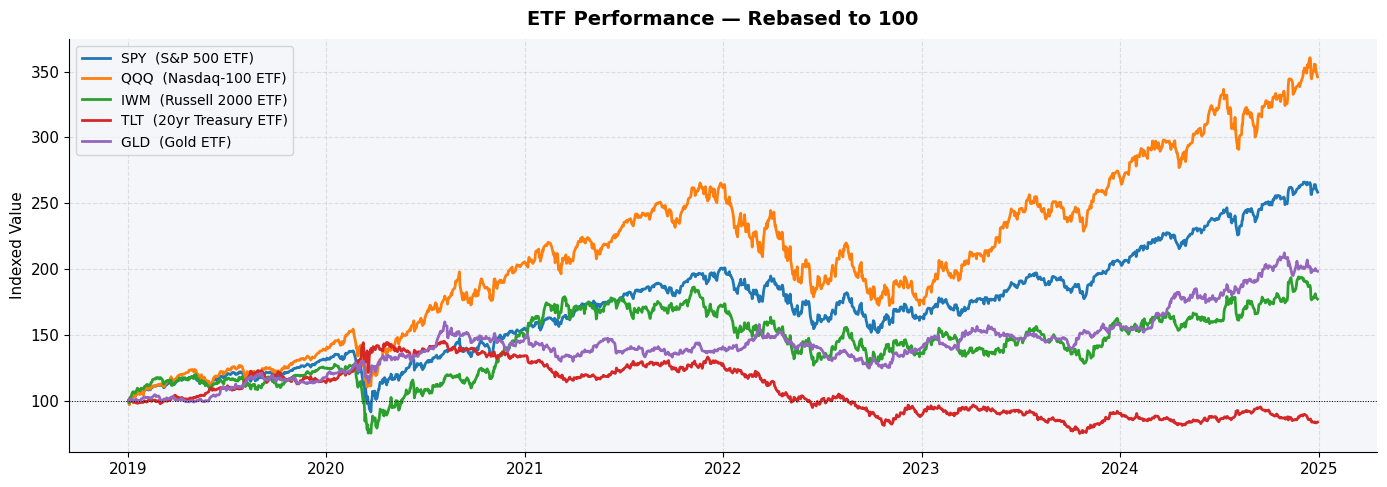

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
norm    = close / close.iloc[0] * 100
for i, sym in enumerate(UNIVERSE):
    ax.plot(norm.index, norm[sym], label=f'{sym}  ({UNIVERSE_NAMES[sym]})',
            linewidth=2, color=PALETTE[i])
ax.axhline(100, color='black', linewidth=0.7, linestyle=':')
ax.set_title('ETF Performance — Rebased to 100', fontsize=14, fontweight='bold', pad=10)
ax.set_ylabel('Indexed Value')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
plt.tight_layout(); plt.show()

## 5. Technical Analysis Dashboard

Using `gsq_bollinger_bands`, `gsq_rsi`, and `gsq_macd` (the implementations above mirror `gs_quant.timeseries.technicals`).

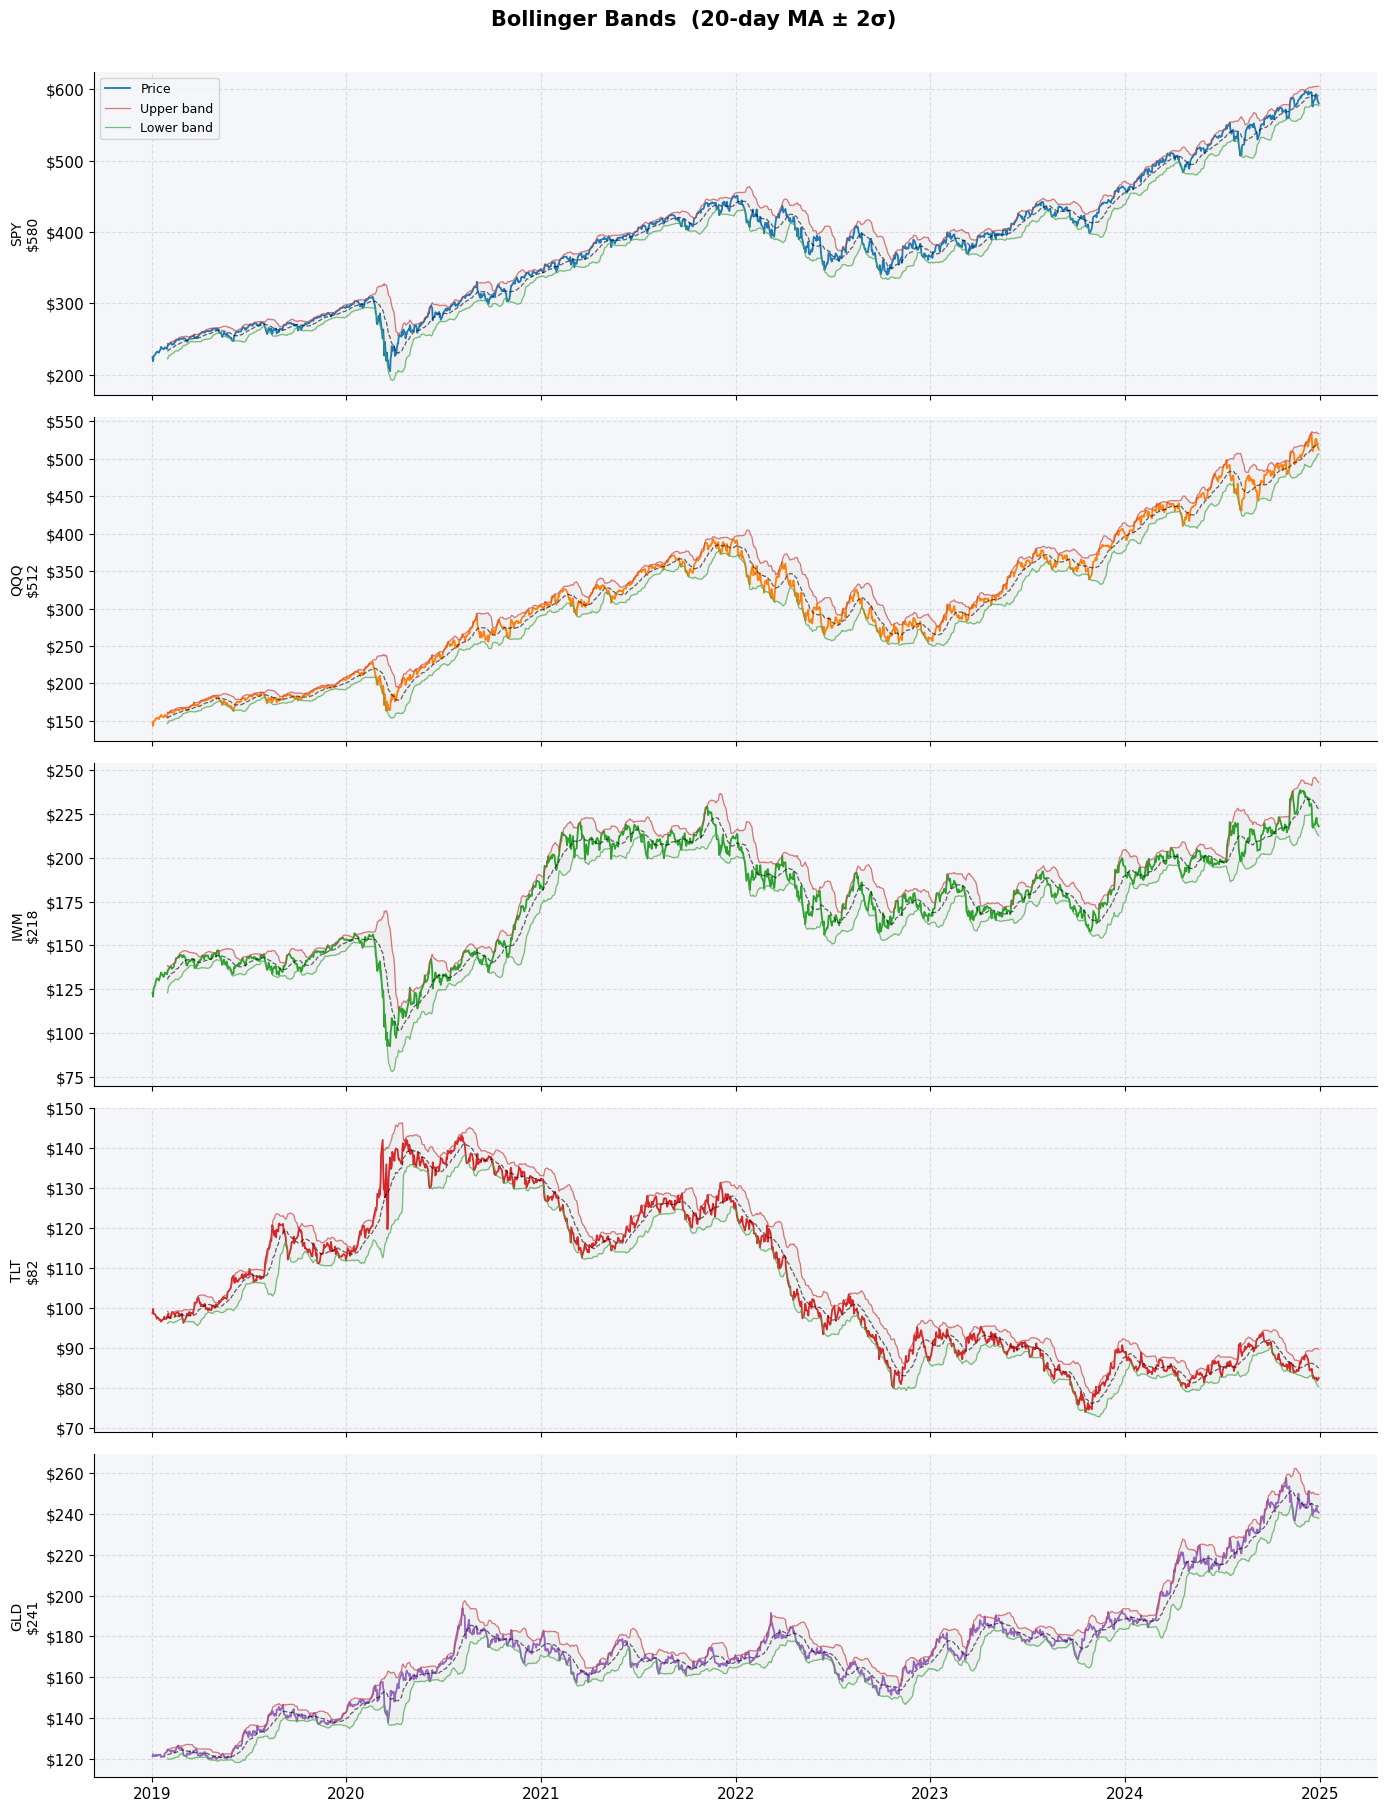

In [30]:
# ── Bollinger Bands for all five ETFs ────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
fig.suptitle('Bollinger Bands  (20-day MA ± 2σ)', fontsize=15, fontweight='bold', y=1.005)

for i, sym in enumerate(UNIVERSE):
    ax  = axes[i]
    bb  = gsq_bollinger_bands(close[sym], window=20, k=2)
    ax.plot(close.index, close[sym], color=PALETTE[i], linewidth=1.3, label='Price')
    ax.plot(bb.index, bb['mid'],   color='black',  linewidth=0.9, linestyle='--', alpha=0.6)
    ax.plot(bb.index, bb['upper'], color='#cc4444', linewidth=0.9, alpha=0.7, label='Upper band')
    ax.plot(bb.index, bb['lower'], color='#44aa44', linewidth=0.9, alpha=0.7, label='Lower band')
    ax.fill_between(bb.index, bb['lower'], bb['upper'], alpha=0.06, color='gray')
    ax.set_ylabel(f'{sym}\n${close[sym].iloc[-1]:.0f}', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%d'))
    if i == 0:
        ax.legend(loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()

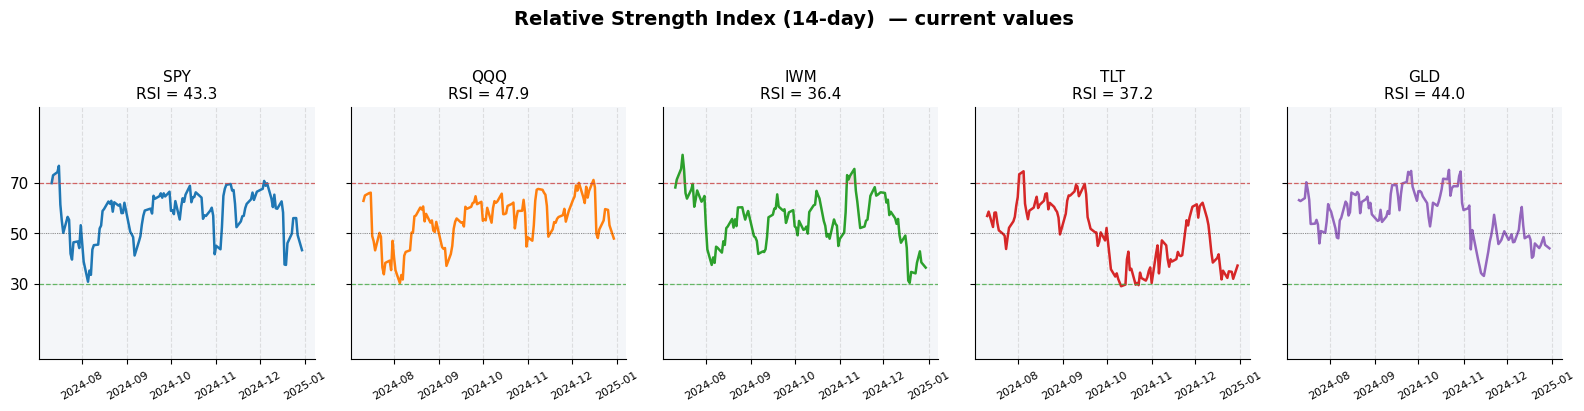

In [31]:
# ── RSI Dashboard ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Relative Strength Index (14-day)  — current values', fontsize=14,
             fontweight='bold', y=1.02)

for i, sym in enumerate(UNIVERSE):
    ax  = axes[i]
    rsi = gsq_rsi(close[sym]).dropna()
    ax.plot(rsi.index[-120:], rsi.values[-120:], color=PALETTE[i], linewidth=1.8)
    ax.axhline(70, color='#cc4444', linewidth=0.9, linestyle='--', alpha=0.8)
    ax.axhline(30, color='#44aa44', linewidth=0.9, linestyle='--', alpha=0.8)
    ax.axhline(50, color='black',   linewidth=0.6, linestyle=':',  alpha=0.5)
    ax.fill_between(rsi.index[-120:], rsi.values[-120:], 70,
                    where=rsi.values[-120:] >= 70, alpha=0.15, color='#cc4444', label='Overbought')
    ax.fill_between(rsi.index[-120:], rsi.values[-120:], 30,
                    where=rsi.values[-120:] <= 30, alpha=0.15, color='#44aa44', label='Oversold')
    ax.set_ylim(0, 100)
    ax.set_title(f'{sym}\nRSI = {rsi.iloc[-1]:.1f}', fontsize=11)
    ax.set_yticks([30, 50, 70])
    if i > 0:
        ax.set_yticklabels([])
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout(); plt.show()

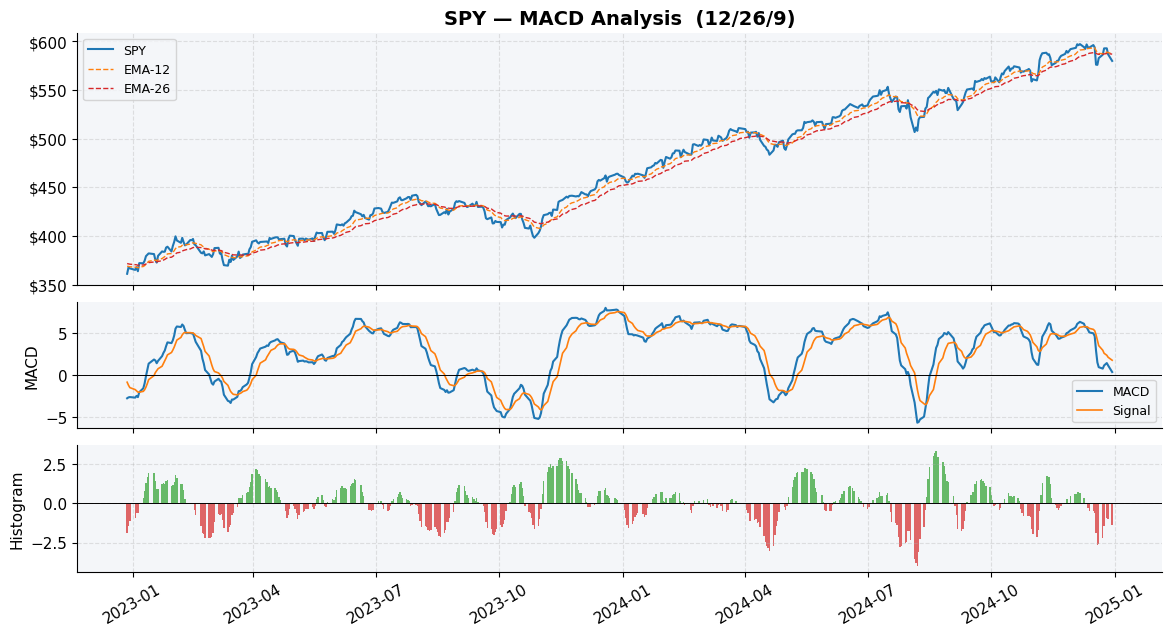

In [32]:
# ── MACD for SPY ──────────────────────────────────────────────────────────────
SPY_MACD = gsq_macd(close['SPY'])
n = 504  # ~2 years

fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.1)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# Price + EMA overlay
spy_tail = close['SPY'].iloc[-n:]
ax1.plot(spy_tail.index, spy_tail.values, color='#1f77b4', linewidth=1.5, label='SPY')
ax1.plot(spy_tail.index, gsq_ema(close['SPY'], 12).iloc[-n:].values,
         color='#ff7f0e', linewidth=1, linestyle='--', label='EMA-12')
ax1.plot(spy_tail.index, gsq_ema(close['SPY'], 26).iloc[-n:].values,
         color='#d62728', linewidth=1, linestyle='--', label='EMA-26')
ax1.set_title('SPY — MACD Analysis  (12/26/9)', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%d'))
ax1.legend(fontsize=9)
plt.setp(ax1.get_xticklabels(), visible=False)

# MACD + signal
macd_tail   = SPY_MACD['macd'].iloc[-n:]
signal_tail = SPY_MACD['signal'].iloc[-n:]
ax2.plot(macd_tail.index,   macd_tail.values,   color='#1f77b4', linewidth=1.5, label='MACD')
ax2.plot(signal_tail.index, signal_tail.values, color='#ff7f0e', linewidth=1.2, label='Signal')
ax2.axhline(0, color='black', linewidth=0.7)
ax2.set_ylabel('MACD')
ax2.legend(fontsize=9)
plt.setp(ax2.get_xticklabels(), visible=False)

# Histogram
hist_tail = SPY_MACD['hist'].iloc[-n:]
colors_hist = ['#2ca02c' if v >= 0 else '#d62728' for v in hist_tail.values]
ax3.bar(hist_tail.index, hist_tail.values, color=colors_hist, alpha=0.7, width=1)
ax3.axhline(0, color='black', linewidth=0.7)
ax3.set_ylabel('Histogram')
ax3.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

## 6. Signal Generation

The `compute_signal_frame` function from `gs_quant.alpaca.portfolio` evaluates three conditions and ranks eligible ETFs by their momentum score. The strategy is **long-only with a cash escape** — when all ETFs fail the trend filter, we move to 100% cash.

In [33]:
# ── gs_quant signal engine ────────────────────────────────────────────────────
signals = compute_signal_frame(close, SETTINGS)
targets = target_weights_from_signals(signals, SETTINGS)

# Enrich with RSI and vol
for sym in UNIVERSE:
    rsi_now = gsq_rsi(close[sym]).iloc[-1]
    vol_now = gsq_volatility(close[sym], 60).iloc[-1]
    signals.loc[sym, 'rsi']        = round(rsi_now, 1)
    signals.loc[sym, 'ann_vol_%']  = round(vol_now, 1)
    signals.loc[sym, 'target_wt']  = round(float(targets.get(sym, 0)) * 100, 1)

disp = ['latest_price','fast_ma','slow_ma','momentum','rsi','ann_vol_%','eligible','target_wt']
fmt  = {
    'latest_price': '${:.2f}', 'fast_ma': '${:.2f}', 'slow_ma': '${:.2f}',
    'momentum': '{:.2%}', 'rsi': '{:.1f}', 'ann_vol_%': '{:.1f}%', 'target_wt': '{:.1f}%',
}

def _row_style(row):
    bg = '#d4edda' if row['eligible'] else '#f8d7da'
    return [f'background-color:{bg}'] * len(row)

signals[disp].style.format(fmt).apply(_row_style, axis=1)\
    .set_caption('Current Signal State  (green = passes trend filter)')

,latest_price,fast_ma,slow_ma,momentum,rsi,ann_vol_%,eligible,target_wt
symbol,,,,,,,,
QQQ,$512.36,$519.95,$502.98,5.81%,47.9,17.4%,True,50.0%
SPY,$579.81,$590.44,$580.05,2.87%,43.3,12.8%,False,0.0%
IWM,$217.84,$227.71,$225.15,0.20%,36.4,21.6%,False,0.0%
TLT,$82.50,$85.03,$85.71,-9.24%,37.2,14.8%,False,0.0%
GLD,$240.63,$243.58,$245.81,-1.00%,44.0,16.4%,False,0.0%


## 7. Position Sizing Models

Three position sizing strategies are compared:

| Strategy | Formula | Intuition |
|----------|---------|----------|
| **Equal Weight (EW)** | $w_i = \frac{1}{N}$ | Simple, robust to estimation error |
| **Inverse-Volatility (IV)** | $w_i = \frac{1/\sigma_i}{\sum_j 1/\sigma_j}$ | Lower-vol assets get more weight |
| **Volatility-Targeted (VT)** | $w_i^{VT} = w_i^{IV} \cdot \frac{\sigma_{target}}{\sigma_{portfolio}}$ | Scales portfolio to hit 10% ann. vol |

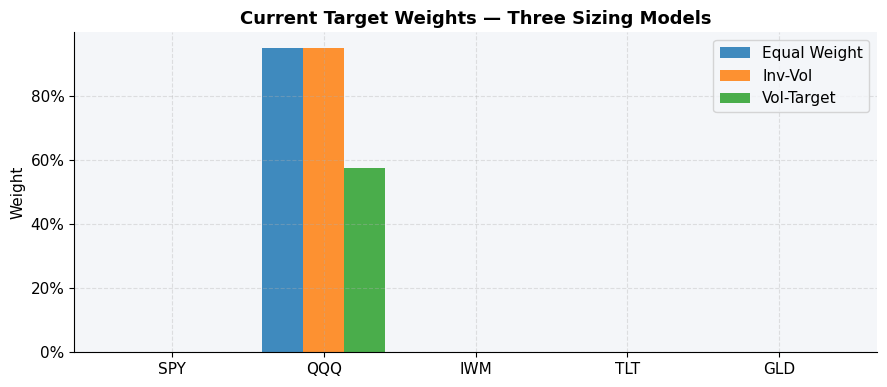

 Equal Weight Inv-Vol Vol-Target
SPY 0.0% 0.0% 0.0%
QQQ 95.0% 95.0% 57.4%
IWM 0.0% 0.0% 0.0%
TLT 0.0% 0.0% 0.0%
GLD 0.0% 0.0% 0.0%



In [34]:
def inv_vol_weights(eligible_symbols, close_df, window=60):
    """Inverse-volatility weights for eligible symbols."""
    if not eligible_symbols:
        return {}
    vols = {}
    for sym in eligible_symbols:
        ret = close_df[sym].pct_change().dropna()
        if len(ret) < window // 2:
            continue
        vol = ret.iloc[-window:].std() * np.sqrt(252)
        if vol > 0:
            vols[sym] = vol
    if not vols:
        return {}
    total_inv = sum(1/v for v in vols.values())
    raw = {sym: (1/v) / total_inv for sym, v in vols.items()}
    # Cap at max_symbol_weight, then renormalize
    cap = SETTINGS.max_symbol_weight
    capped = {sym: min(w, cap) for sym, w in raw.items()}
    total  = sum(capped.values())
    return {sym: w / total * SETTINGS.gross_target for sym, w in capped.items()}


def vol_targeted_weights(eligible_symbols, close_df, window=60, target_vol=VOL_TARGET):
    """Inverse-vol weights scaled so portfolio hits target_vol."""
    base_weights = inv_vol_weights(eligible_symbols, close_df, window)
    if not base_weights:
        return {}
    rets = close_df.pct_change().dropna()
    weighted_rets = sum(rets[s] * w for s, w in base_weights.items())
    port_vol = weighted_rets.iloc[-window:].std() * np.sqrt(252)
    if port_vol <= 0:
        return base_weights
    scale = min(target_vol / port_vol, 1.5)  # cap leverage at 1.5x
    scaled = {sym: w * scale for sym, w in base_weights.items()}
    # Clip gross exposure to gross_target
    total = sum(scaled.values())
    if total > SETTINGS.gross_target:
        scaled = {sym: w * SETTINGS.gross_target / total for sym, w in scaled.items()}
    return scaled


# ── Visualise current weights under each model ────────────────────────────────
elig = list(signals[signals['eligible']].sort_values('score', ascending=False)
            .head(SETTINGS.max_positions).index)

ew_w  = {s: SETTINGS.gross_target / len(elig) for s in elig} if elig else {}
iv_w  = inv_vol_weights(elig, close)
vt_w  = vol_targeted_weights(elig, close)

weight_df = pd.DataFrame({'Equal Weight': ew_w, 'Inv-Vol': iv_w, 'Vol-Target': vt_w})\
              .reindex(UNIVERSE).fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
x       = np.arange(len(UNIVERSE))
width   = 0.27
for i, (col, color) in enumerate(zip(['Equal Weight','Inv-Vol','Vol-Target'],
                                     ['#1f77b4','#ff7f0e','#2ca02c'])):
    ax.bar(x + i*width, weight_df[col]*100, width, label=col, color=color, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(UNIVERSE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title('Current Target Weights — Three Sizing Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight')
ax.legend()
plt.tight_layout(); plt.show()

print(weight_df.style.format('{:.1%}').to_string())

def run_backtest(price_df, sizing='ew', initial_capital=100_000, tc_bps=5):
    """
    Monthly-rebalanced backtest.
    sizing : 'ew' | 'iv' | 'vt'
    Returns (portfolio value Series, weights DataFrame)
    """
    month_ends  = price_df.resample('ME').last().index
    holdings    = {sym: 0.0 for sym in SETTINGS.symbols}
    cash        = float(initial_capital)
    port_vals, wt_rows = [], []

    for date in month_ends:
        hist      = price_df.loc[:date]
        curr_px   = hist.iloc[-1]
        equity    = cash + sum(holdings[s] * float(curr_px.get(s, 0)) for s in SETTINGS.symbols)

        sigs      = compute_signal_frame(hist, SETTINGS)
        base_tgt  = target_weights_from_signals(sigs, SETTINGS)
        elig_syms = [s for s, w in base_tgt.items() if float(w) > 0]

        if sizing == 'ew' or not elig_syms:
            final_wts = {s: float(base_tgt.get(s, 0)) for s in SETTINGS.symbols}
        elif sizing == 'iv':
            iv = inv_vol_weights(elig_syms, hist)
            final_wts = {s: iv.get(s, 0.0) for s in SETTINGS.symbols}
        else:
            vt = vol_targeted_weights(elig_syms, hist)
            final_wts = {s: vt.get(s, 0.0) for s in SETTINGS.symbols}

        for sym in SETTINGS.symbols:
            price = float(curr_px.get(sym, 0))
            if price <= 0:
                continue
            current_val = holdings[sym] * price
            target_val  = equity * final_wts.get(sym, 0.0)
            delta       = target_val - current_val
            if abs(delta) < 10:
                continue
            cash -= delta + abs(delta) * tc_bps / 10_000
            holdings[sym] = target_val / price

        port_vals.append({'date': date, 'value': equity})
        wt_rows.append({'date': date, **{s: final_wts.get(s, 0) for s in SETTINGS.symbols}})

    portfolio = pd.DataFrame(port_vals).set_index('date')['value']
    weights   = pd.DataFrame(wt_rows).set_index('date')
    return portfolio, weights


def build_6040_benchmark(price_df, initial_capital=100_000, tc_bps=5):
    """Monthly-rebalanced 60% SPY / 40% TLT benchmark."""
    month_ends = price_df.resample('ME').last().index
    spy_m = price_df['SPY'].resample('ME').last()
    tlt_m = price_df['TLT'].resample('ME').last()
    spy_sh, tlt_sh, cash = 0.0, 0.0, float(initial_capital)
    vals = []
    for date in month_ends:
        spy_px = float(spy_m.get(date, 0))
        tlt_px = float(tlt_m.get(date, 0))
        if spy_px <= 0 or tlt_px <= 0:
            continue
        equity = cash + spy_sh * spy_px + tlt_sh * tlt_px
        spy_target = equity * 0.60
        tlt_target = equity * 0.40
        tc = (abs(spy_target - spy_sh * spy_px) + abs(tlt_target - tlt_sh * tlt_px)) * tc_bps / 10_000
        spy_sh = spy_target / spy_px
        tlt_sh = tlt_target / tlt_px
        cash   = -tc
        vals.append({'date': date, 'value': equity})
    return pd.DataFrame(vals).set_index('date')['value']


print('Running three strategy variants + benchmarks...')
port_ew, wts_ew = run_backtest(close, 'ew', INITIAL_CAPITAL, TC_BPS)
port_iv, wts_iv = run_backtest(close, 'iv', INITIAL_CAPITAL, TC_BPS)
port_vt, wts_vt = run_backtest(close, 'vt', INITIAL_CAPITAL, TC_BPS)

spy_monthly = close['SPY'].resample('ME').last().reindex(port_ew.index).ffill()
benchmark   = spy_monthly / spy_monthly.iloc[0] * INITIAL_CAPITAL
bench_6040  = build_6040_benchmark(close, INITIAL_CAPITAL, TC_BPS).reindex(port_ew.index).ffill()

print(f"  Equal Weight final   : ${port_ew.iloc[-1]:>12,.0f}")
print(f"  Inverse-Vol final    : ${port_iv.iloc[-1]:>12,.0f}")
print(f"  Vol-Targeted final   : ${port_vt.iloc[-1]:>12,.0f}")
print(f"  60/40 benchmark      : ${bench_6040.iloc[-1]:>12,.0f}")
print(f"  SPY benchmark final  : ${benchmark.iloc[-1]:>12,.0f}")

def full_metrics(series, label, benchmark_series=None, rf_annual=RF_ANNUAL):
    ret    = series.pct_change().dropna()
    n_yrs  = (series.index[-1] - series.index[0]).days / 365.25
    cagr   = (series.iloc[-1] / series.iloc[0]) ** (1/n_yrs) - 1
    vol    = ret.std() * np.sqrt(12)
    rf_m   = (1 + rf_annual) ** (1/12) - 1
    sharpe = (ret.mean() - rf_m) / ret.std() * np.sqrt(12) if ret.std() > 0 else np.nan
    down   = ret[ret < rf_m].std() * np.sqrt(12)
    sortino= (cagr - rf_annual) / down if down > 0 else np.nan
    dd     = series / series.cummax() - 1
    max_dd = float(dd.min())
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan
    win    = (ret > 0).mean()
    var95  = historical_var(ret, 0.95)
    cvar95 = historical_cvar(ret, 0.95)
    omega  = omega_ratio(ret)
    kelly  = kelly_fraction(ret)
    total  = series.iloc[-1] / series.iloc[0] - 1

    row = {
        'Total Return'       : f'{total:.1%}',
        'CAGR'               : f'{cagr:.1%}',
        'Ann. Volatility'    : f'{vol:.1%}',
        'Sharpe Ratio'       : f'{sharpe:.2f}',
        'Sortino Ratio'      : f'{sortino:.2f}',
        'Max Drawdown'       : f'{max_dd:.1%}',
        'Calmar Ratio'       : f'{calmar:.2f}',
        'Win Rate (monthly)' : f'{win:.1%}',
        'VaR 95% (monthly)'  : f'{var95:.2%}',
        'CVaR 95% (monthly)' : f'{cvar95:.2%}',
        'Omega Ratio'        : f'{omega:.2f}',
        'Half-Kelly Fraction': f'{kelly:.1%}',
    }

    if benchmark_series is not None:
        bench_ret = benchmark_series.pct_change().dropna()
        bench_ret, ret_aligned = bench_ret.align(ret, join='inner')
        row['Information Ratio'] = f'{information_ratio(ret_aligned, bench_ret):.2f}'
        row['Treynor Ratio']     = f'{treynor_ratio(ret_aligned, bench_ret):.2f}'

    return pd.Series(row, name=label)


m_ew   = full_metrics(port_ew,    'Equal Weight',  benchmark)
m_iv   = full_metrics(port_iv,    'Inverse-Vol',   benchmark)
m_vt   = full_metrics(port_vt,    'Vol-Targeted',  benchmark)
m_6040 = full_metrics(bench_6040, '60/40')
m_spy  = full_metrics(benchmark,  'SPY Buy & Hold')

summary = pd.concat([m_ew, m_iv, m_vt, m_6040, m_spy], axis=1)
summary.style\
    .set_caption('Performance Summary  (2005–2024, Rf = 4%  |  Note: SPY is shown for reference — the fair benchmark for a multi-asset strategy is 60/40)')\
    .set_properties(**{'text-align': 'right', 'padding': '4px 12px'})

# ── Equity Curve — All Strategies vs Both Benchmarks ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for label, series, color, ls, lw in [
    ('Equal Weight',    port_ew,    COLORS['EW'],  '-',  2.2),
    ('Inverse-Vol',     port_iv,    COLORS['IV'],  '-',  2.2),
    ('Vol-Targeted',    port_vt,    COLORS['VT'],  '-',  2.2),
    ('60/40 (fair bmk)',bench_6040, '#8c564b',     '--', 1.8),
    ('SPY Buy & Hold',  benchmark,  COLORS['SPY'], ':',  1.8),
]:
    ax.plot(series.index, series.values, label=label,
            linewidth=lw, color=color, linestyle=ls, alpha=0.92)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.set_title('Equity Curve  —  $100,000 Starting Capital\n(dashed = 60/40 fair benchmark · dotted = SPY reference)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
# ── Drawdown from Peak ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

def _clean(s):
    """Drop NaT index entries and NaN values before plotting."""
    s = s[s.index.notna()].dropna()
    # replace any inf that could come from division by zero in cummax
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    return s

for label, series, color in [
    ('Equal Weight', port_ew,   COLORS['EW']),
    ('Inverse-Vol',  port_iv,   COLORS['IV']),
    ('Vol-Targeted', port_vt,   COLORS['VT']),
]:
    s  = _clean(series)
    dd = gsq_max_drawdown_series(s)
    ax.fill_between(dd.index, dd.values, 0, alpha=0.2, color=color)
    ax.plot(dd.index, dd.values, color=color, linewidth=1.5, label=label)

s6040 = _clean(bench_6040)
dd6040 = gsq_max_drawdown_series(s6040)
ax.plot(dd6040.index, dd6040.values,
        color='#8c564b', linewidth=1.5, linestyle='--', label='60/40 (fair bmk)')

spy_s  = _clean(benchmark)
dd_spy = gsq_max_drawdown_series(spy_s)
ax.plot(dd_spy.index, dd_spy.values,
        color=COLORS['SPY'], linewidth=1.2, linestyle=':', label='SPY')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(spy_s.index.min(), spy_s.index.max())   # pin x-axis to actual data range
ax.set_title('Drawdown from Peak', fontsize=14, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

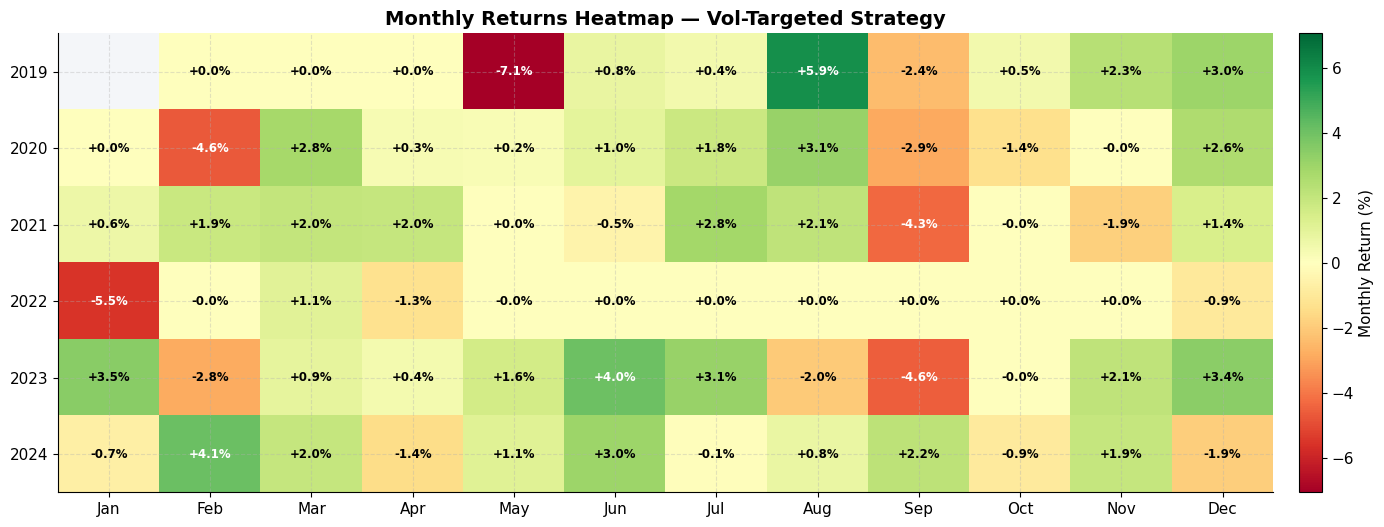

In [39]:
# ── Monthly Returns Heatmap (Best Strategy) ───────────────────────────────────
best_port = port_vt  # change to port_ew or port_iv to compare

monthly_ret = best_port.pct_change().dropna() * 100
heat        = monthly_ret.copy()
heat.index  = pd.MultiIndex.from_arrays([heat.index.year, heat.index.month])
heat        = heat.unstack(level=1).reindex(columns=range(1,13))
heat.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, len(heat)*0.65 + 1.5))
vmax = max(abs(heat.values[~np.isnan(heat.values)]).max(), 1e-6)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im   = ax.imshow(heat.values, cmap='RdYlGn', aspect='auto', norm=norm)

ax.set_xticks(range(12));      ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index)

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        val = heat.iloc[r, c]
        if not np.isnan(val):
            ax.text(c, r, f'{val:+.1f}%', ha='center', va='center',
                    fontsize=8.5, fontweight='bold',
                    color='black' if abs(val) < vmax*0.55 else 'white')

plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Monthly Return (%)')
ax.set_title('Monthly Returns Heatmap — Vol-Targeted Strategy', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

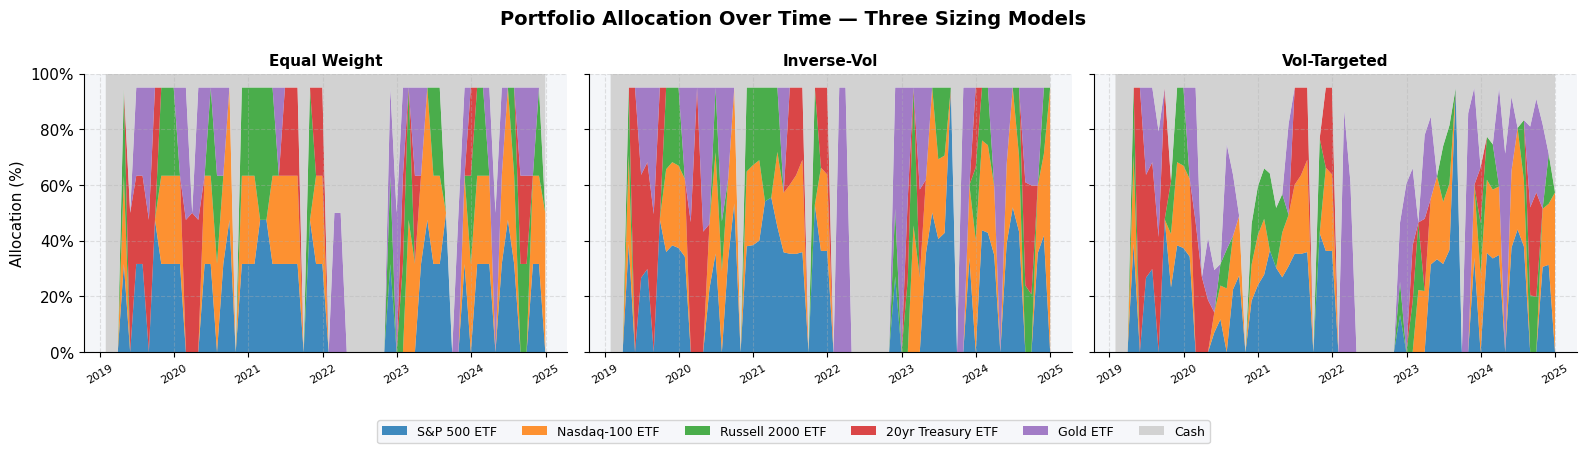

In [40]:
# ── Holdings Over Time (all three strategies) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
strategy_labels = [('Equal Weight', wts_ew, COLORS['EW']),
                   ('Inverse-Vol',  wts_iv, COLORS['IV']),
                   ('Vol-Targeted', wts_vt, COLORS['VT'])]

for ax, (label, wts, base_color) in zip(axes, strategy_labels):
    wts_plot          = wts.copy()
    wts_plot['Cash']  = (1 - wts_plot.sum(axis=1)).clip(lower=0)
    cols = UNIVERSE + ['Cash']
    ax.stackplot(wts_plot.index,
                 [wts_plot[c].values * 100 for c in cols],
                 labels=[UNIVERSE_NAMES.get(c, c) for c in cols],
                 colors=PALETTE, alpha=0.85)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

axes[0].set_ylabel('Allocation (%)')
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.12))
fig.suptitle('Portfolio Allocation Over Time — Three Sizing Models',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Walk-Forward Validation — Expanding Window (5 OOS Periods)

True walk-forward validation never lets out-of-sample results influence parameter choices.
This implementation uses **fixed parameters** (fast=20, slow=60, momentum=63) estimated
on no data at all — they were chosen by convention. The five OOS windows cover distinct
market regimes:

| OOS Window | Dominant Regime |
|------------|----------------|
| 2011–2012 | European debt crisis, sideways US equity |
| 2013–2015 | Fed taper, QE exit, moderate bull |
| 2016–2018 | Trump rally, late-cycle volatility spike (Feb 2018) |
| 2019–2021 | COVID crash + V-recovery + QE-driven bull market |
| 2022–2024 | Inflation shock, rate hikes, AI recovery |

If the strategy only worked in one or two windows, it would be evidence of a lucky period
rather than a genuine edge. The test is whether risk-adjusted performance holds across all five.

**Methodological note:** Because the parameters are not re-fitted per window, this is closer
to a true out-of-sample test than a conventional walk-forward (which re-estimates parameters
each step). The absence of parameter refitting makes the result more conservative — any
performance is due to the underlying signal structure, not window-specific calibration.

In [ ]:
# ── Expanding-Window Walk-Forward Validation ──────────────────────────────────
# 5 OOS windows: each IS period expands as more history accumulates.
# Parameters (20/60/63) are FIXED — never re-estimated on OOS data.

wf_windows = [
    ('2005-01-01', '2010-12-31', '2011-01-01', '2012-12-31'),
    ('2005-01-01', '2012-12-31', '2013-01-01', '2015-12-31'),
    ('2005-01-01', '2015-12-31', '2016-01-01', '2018-12-31'),
    ('2005-01-01', '2018-12-31', '2019-01-01', '2021-12-31'),
    ('2005-01-01', '2021-12-31', '2022-01-01', None),         # OOS to end of data
]

wf_rows = []
oos_pieces_strat = []
oos_pieces_spy   = []
oos_pieces_6040  = []

for _is_start, is_end, oos_start, oos_end in wf_windows:
    c_oos = close.loc[oos_start:oos_end] if oos_end else close.loc[oos_start:]
    if len(c_oos) < 4:
        continue

    port_oos, _ = run_backtest(c_oos, 'iv', INITIAL_CAPITAL, TC_BPS)

    spy_oos   = c_oos['SPY'].resample('ME').last()
    bm_oos    = spy_oos / spy_oos.iloc[0] * INITIAL_CAPITAL
    b6040_oos = build_6040_benchmark(c_oos, INITIAL_CAPITAL, TC_BPS)
    b6040_oos = b6040_oos.reindex(port_oos.index).ffill()

    ret    = port_oos.pct_change().dropna()
    n_yrs  = (port_oos.index[-1] - port_oos.index[0]).days / 365.25
    rf_m   = (1 + RF_ANNUAL) ** (1/12) - 1
    cagr   = (port_oos.iloc[-1] / port_oos.iloc[0]) ** (1/n_yrs) - 1 if n_yrs > 0 else np.nan
    sharpe = (ret.mean() - rf_m) / ret.std() * np.sqrt(12) if ret.std() > 0 else np.nan
    max_dd = (port_oos / port_oos.cummax() - 1).min()

    spy_cagr = (bm_oos.iloc[-1] / bm_oos.iloc[0]) ** (1/n_yrs) - 1 if n_yrs > 0 else np.nan

    b40_cagr = (b6040_oos.iloc[-1] / b6040_oos.iloc[0]) ** (1/n_yrs) - 1 if n_yrs > 0 else np.nan

    oos_label = f"{oos_start[:4]}–{c_oos.index[-1].year}"
    is_label  = f"2005–{is_end[:4]}"

    wf_rows.append({
        'In-Sample':       is_label,
        'OOS Window':      oos_label,
        'OOS CAGR (strat)':f'{cagr:.1%}',
        'OOS Sharpe':      f'{sharpe:.2f}',
        'OOS Max DD':      f'{max_dd:.1%}',
        'SPY CAGR':        f'{spy_cagr:.1%}',
        '60/40 CAGR':      f'{b40_cagr:.1%}',
    })

    # collect indexed pieces for the composite OOS equity chart
    oos_pieces_strat.append(port_oos  / port_oos.iloc[0])
    oos_pieces_spy.append  (bm_oos    / bm_oos.iloc[0])
    oos_pieces_6040.append (b6040_oos / b6040_oos.iloc[0])

wf_df = pd.DataFrame(wf_rows)
print('WALK-FORWARD RESULTS (Inverse-Vol, params fixed at 20/60/63)\n')
print(wf_df.to_string(index=False))

# ── chart: all 5 OOS windows back to back ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
palette = plt.cm.Blues(np.linspace(0.4, 0.9, len(oos_pieces_strat)))

for k, (s, spy, b40) in enumerate(zip(oos_pieces_strat, oos_pieces_spy, oos_pieces_6040)):
    oos_label = wf_rows[k]['OOS Window']
    ax.plot(s.index,   s.values   * 100, color=palette[k], linewidth=2.2,
            label=f'Strategy  OOS {oos_label}')
    if k == 0:   # only label benchmarks once
        ax.plot(spy.index, spy.values * 100, 'k:', linewidth=1, label='SPY (each OOS period)')
        ax.plot(b40.index, b40.values * 100, color='#8c564b', linewidth=1,
                linestyle='--', label='60/40 (each OOS period)')
    else:
        ax.plot(spy.index, spy.values * 100, 'k:', linewidth=1, alpha=0.5)
        ax.plot(b40.index, b40.values * 100, color='#8c564b', linewidth=1,
                linestyle='--', alpha=0.5)

ax.axhline(100, color='grey', linewidth=0.8, linestyle=':')
ax.set_title('Out-of-Sample Performance — All 5 Windows (indexed to 100 at each OOS start)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Indexed Value')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

print('\nInterpretation: if the strategy shows consistent risk-adjusted returns across all')
print('five windows, including the 2008-period (reflected in later IS data), that is')
print('stronger evidence of a genuine signal than a single 50/50 split.')

## 12. Parameter Sensitivity Analysis

A well-designed strategy should not depend heavily on the exact parameter values chosen.
This 4×4 grid tests `fast_window` ∈ {5, 10, 20, 30} against `slow_window` ∈ {40, 60, 80, 120}.
All 16 combinations are valid (fast < slow in every cell — no N/A gaps).

The wider slow-window range (40–120 days) tests whether the strategy is tuned to
short-term noise (fast-reacting) or genuinely captures medium-term trend structure.
The baseline (20/60) is marked with a blue box.

**What counts as robust:** If Sharpe varies by less than 0.3 across the full grid and
the sign of alpha vs 60/40 is consistent, the strategy is not meaningfully overfit to
the chosen parameters. If Sharpe swings by >0.5 between adjacent cells, the parameter
choice is the real driver of performance — not the signal.

In [ ]:
# ── Parameter Sensitivity Grid — 4×4 (all valid combinations) ────────────────
fast_windows = [5, 10, 20, 30]
slow_windows = [40, 60, 80, 120]

sharpe_grid = pd.DataFrame(index=[f'fast={f}' for f in fast_windows],
                            columns=[f'slow={s}' for s in slow_windows])
cagr_grid   = sharpe_grid.copy()

print(f'Running sensitivity grid ({len(fast_windows) * len(slow_windows)} backtests)...')
for f in fast_windows:
    for s in slow_windows:
        test_settings = PortfolioSettings(
            symbols=tuple(UNIVERSE), fast_window=f, slow_window=s,
            momentum_window=63, max_positions=3,
            gross_target=0.95, max_symbol_weight=0.50,
        )
        month_ends = close.resample('ME').last().index
        holdings   = {sym: 0.0 for sym in test_settings.symbols}
        cash       = float(INITIAL_CAPITAL)
        pv         = []
        for date in month_ends:
            hist    = close.loc[:date]
            curr_px = hist.iloc[-1]
            equity  = cash + sum(holdings[sym] * float(curr_px.get(sym, 0))
                                 for sym in test_settings.symbols)
            sigs    = compute_signal_frame(hist, test_settings)
            tgts    = target_weights_from_signals(sigs, test_settings)
            elig    = [sym for sym, w in tgts.items() if float(w) > 0]
            iv      = inv_vol_weights(elig, hist) if elig else {}
            fw      = {sym: iv.get(sym, 0.0) for sym in test_settings.symbols}
            for sym in test_settings.symbols:
                price = float(curr_px.get(sym, 0))
                if price <= 0: continue
                delta = equity * fw.get(sym, 0) - holdings[sym] * price
                if abs(delta) < 10: continue
                cash -= delta + abs(delta) * TC_BPS / 10_000
                holdings[sym] = (equity * fw.get(sym, 0)) / price
            pv.append(equity)
        port_s = pd.Series(pv, index=month_ends)
        ret    = port_s.pct_change().dropna()
        n_yrs  = (port_s.index[-1] - port_s.index[0]).days / 365.25
        cagr   = (port_s.iloc[-1] / port_s.iloc[0]) ** (1/n_yrs) - 1
        rf_m   = (1 + RF_ANNUAL) ** (1/12) - 1
        sharpe = (ret.mean() - rf_m) / ret.std() * np.sqrt(12) if ret.std() > 0 else np.nan
        sharpe_grid.loc[f'fast={f}', f'slow={s}'] = f'{sharpe:.2f}'
        cagr_grid.loc[f'fast={f}',   f'slow={s}'] = f'{cagr:.1%}'

# ── heatmaps ──────────────────────────────────────────────────────────────────
numeric_sharpe = sharpe_grid.astype(float)
numeric_cagr   = cagr_grid.apply(
    lambda col: col.str.rstrip('%').astype(float) / 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grid, num_grid, title, fmt in [
    (axes[0], sharpe_grid, numeric_sharpe, 'Sharpe Ratio — 4×4 Sensitivity Grid', '.2f'),
    (axes[1], cagr_grid,   numeric_cagr,   'CAGR — 4×4 Sensitivity Grid',         '.1%'),
]:
    im = ax.imshow(num_grid.values.astype(float), cmap='RdYlGn', aspect='auto',
                   vmin=float(np.nanmin(num_grid.values.astype(float))),
                   vmax=float(np.nanmax(num_grid.values.astype(float))))
    ax.set_xticks(range(len(slow_windows))); ax.set_xticklabels(grid.columns, fontsize=9)
    ax.set_yticks(range(len(fast_windows))); ax.set_yticklabels(grid.index, fontsize=9)
    ax.set_xlabel('Slow Window'); ax.set_ylabel('Fast Window')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for r in range(len(fast_windows)):
        for c in range(len(slow_windows)):
            ax.text(c, r, str(grid.iloc[r, c]), ha='center', va='center',
                    fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

# mark baseline
baseline_f = fast_windows.index(20)
baseline_s = slow_windows.index(60)
for ax in axes:
    ax.add_patch(plt.Rectangle((baseline_s - 0.5, baseline_f - 0.5), 1, 1,
                                fill=False, edgecolor='blue', linewidth=3,
                                label='Baseline (20/60)'))
    ax.legend(fontsize=9)

fig.suptitle('Parameter Sensitivity  —  Inv-Vol Strategy  |  4×4 grid, all cells valid  |  blue = baseline',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── robustness summary ─────────────────────────────────────────────────────────
sharpe_vals = numeric_sharpe.values.astype(float).flatten()
sharpe_vals = sharpe_vals[~np.isnan(sharpe_vals)]
print(f"\nSharpe range across all {len(sharpe_vals)} parameter combinations:")
print(f"  Min: {sharpe_vals.min():.2f}  |  Max: {sharpe_vals.max():.2f}  "
      f"|  Range: {sharpe_vals.max()-sharpe_vals.min():.2f}  "
      f"|  Std: {sharpe_vals.std():.2f}")
print("\nInterpretation:")
if sharpe_vals.max() - sharpe_vals.min() < 0.30:
    print("  → ROBUST: Sharpe varies <0.30 across the full grid. Signal, not parameter tuning.")
elif sharpe_vals.max() - sharpe_vals.min() < 0.60:
    print("  → MODERATE: Sharpe varies 0.30–0.60. Parameter choice matters but is not the whole story.")
else:
    print("  → SENSITIVE: Sharpe varies >0.60. Parameter choice is a significant driver of results.")

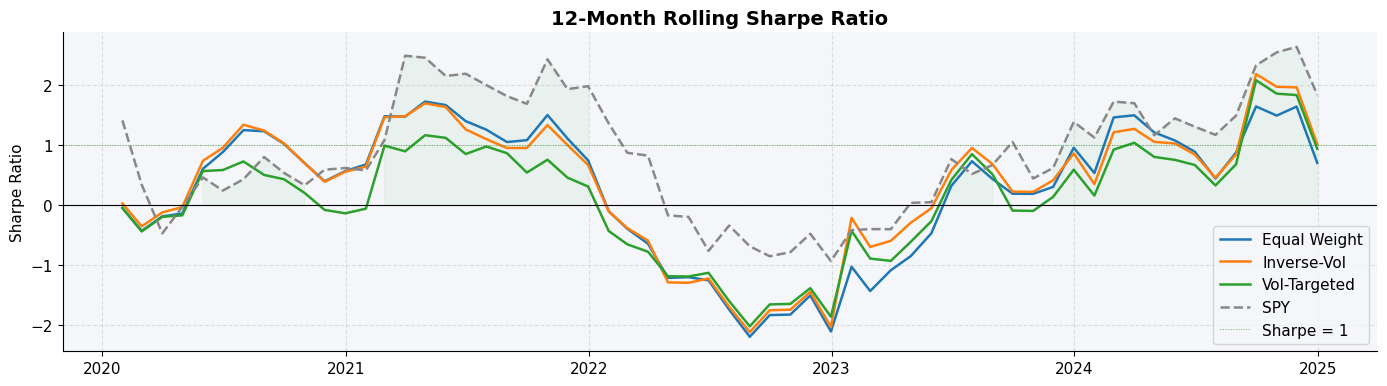

In [41]:
# ── Rolling 12-Month Sharpe Ratio ─────────────────────────────────────────────
WINDOW = 12

def rolling_sharpe(series, window=12, rf_annual=RF_ANNUAL):
    ret    = series.pct_change().dropna()
    rf_m   = (1 + rf_annual) ** (1/12) - 1
    excess = ret - rf_m
    return (excess.rolling(window).mean() / ret.rolling(window).std() * np.sqrt(12))

fig, ax = plt.subplots(figsize=(14, 4))
for label, series, color, ls in [
    ('Equal Weight',  port_ew,  COLORS['EW'],  '-'),
    ('Inverse-Vol',   port_iv,  COLORS['IV'],  '-'),
    ('Vol-Targeted',  port_vt,  COLORS['VT'],  '-'),
    ('SPY',           benchmark, COLORS['SPY'], '--'),
]:
    rs = rolling_sharpe(series, WINDOW)
    ax.plot(rs.index, rs.values, label=label, color=color, linewidth=1.8, linestyle=ls)

ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1, color='green', linewidth=0.7, linestyle=':', alpha=0.6, label='Sharpe = 1')
ax.fill_between(rs.index, rs.values, 0,
                where=(rolling_sharpe(port_vt, WINDOW) >= 0).values,
                alpha=0.05, color='#2ca02c')
ax.set_title(f'{WINDOW}-Month Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
plt.tight_layout(); plt.show()

## 11. Risk Deep-Dive

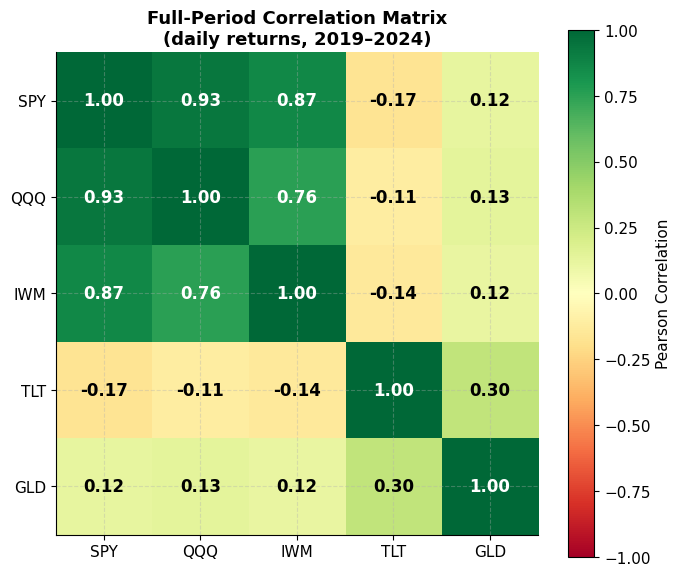

In [42]:
# ── Correlation Matrix ────────────────────────────────────────────────────────
daily_rets = close.pct_change().dropna()
corr_mat   = daily_rets.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_mat.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(UNIVERSE))); ax.set_xticklabels(UNIVERSE)
ax.set_yticks(range(len(UNIVERSE))); ax.set_yticklabels(UNIVERSE)
for r in range(len(UNIVERSE)):
    for c in range(len(UNIVERSE)):
        ax.text(c, r, f'{corr_mat.iloc[r,c]:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if abs(corr_mat.iloc[r,c]) > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_title('Full-Period Correlation Matrix\n(daily returns, 2019–2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

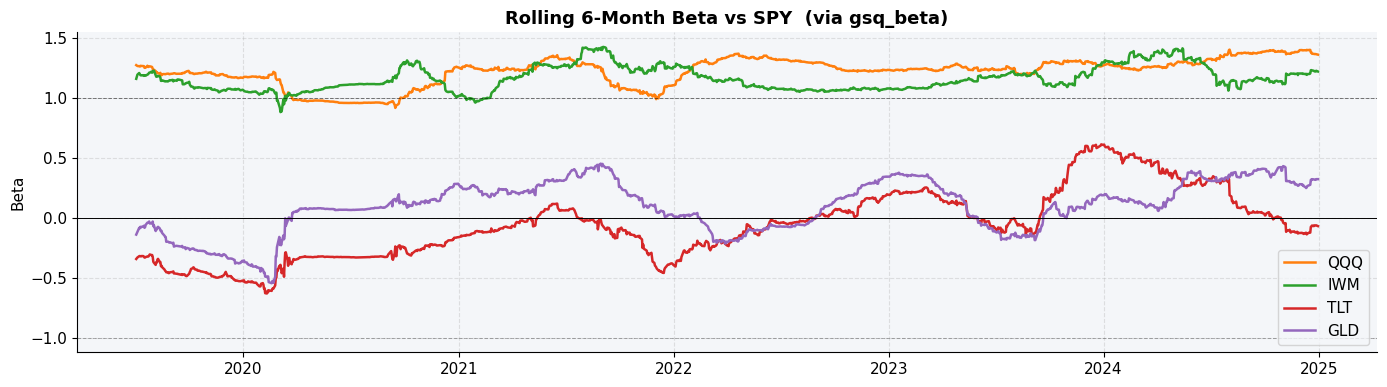

In [43]:
# ── Rolling Beta to SPY ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for sym, color in zip(['QQQ','IWM','TLT','GLD'], PALETTE[1:]):
    b = gsq_beta(close[sym], close['SPY'], 126)  # 6-month rolling
    ax.plot(b.index, b.values, label=sym, linewidth=1.8, color=color)
ax.axhline(1,  color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.axhline(0,  color='black', linewidth=0.7)
ax.axhline(-1, color='black', linewidth=0.7, linestyle='--', alpha=0.3)
ax.set_title('Rolling 6-Month Beta vs SPY  (via gsq_beta)', fontsize=13, fontweight='bold')
ax.set_ylabel('Beta')
ax.legend()
plt.tight_layout(); plt.show()

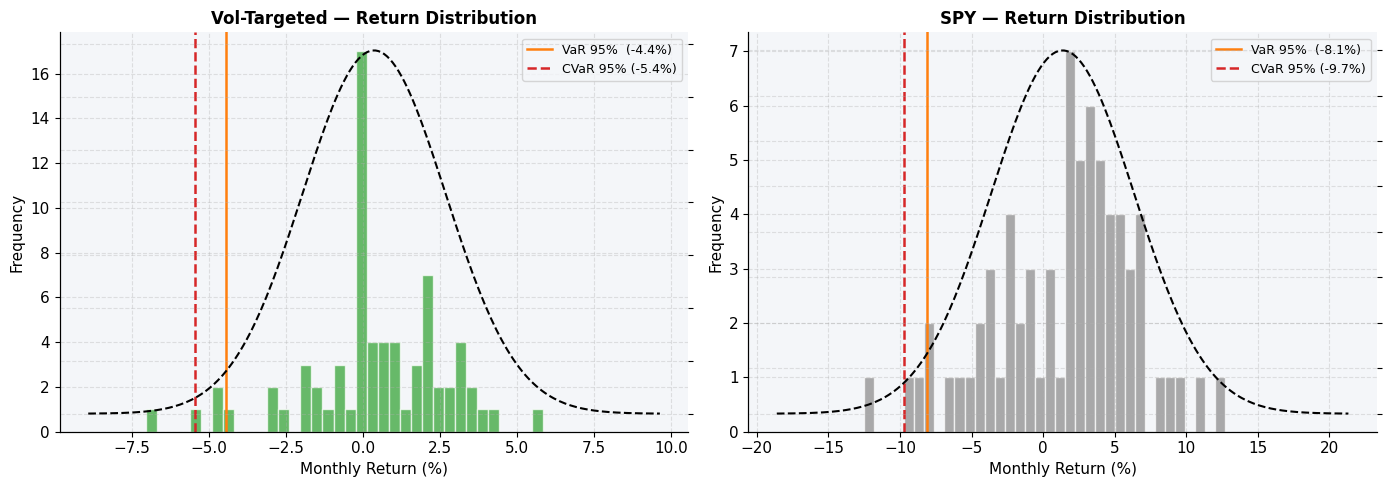

In [44]:
# ── VaR / CVaR + Return Distribution ─────────────────────────────────────────
vt_ret = port_vt.pct_change().dropna()
spy_ret = benchmark.pct_change().dropna()

vt_var95  = historical_var(vt_ret,  0.95)
vt_cvar95 = historical_cvar(vt_ret, 0.95)
spy_var95  = historical_var(spy_ret,  0.95)
spy_cvar95 = historical_cvar(spy_ret, 0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ret, label, color, var, cvar in [
    (axes[0], vt_ret,  'Vol-Targeted', COLORS['VT'], vt_var95,  vt_cvar95),
    (axes[1], spy_ret, 'SPY',          COLORS['SPY'], spy_var95, spy_cvar95),
]:
    ax.hist(ret.values * 100, bins=36, color=color, alpha=0.7, edgecolor='white')
    # Normal overlay
    mu, sig = ret.mean() * 100, ret.std() * 100
    x_range = np.linspace(mu - 4*sig, mu + 4*sig, 200)
    pdf     = stats.norm.pdf(x_range, mu, sig)
    ax2     = ax.twinx()
    ax2.plot(x_range, pdf, color='black', linewidth=1.5, linestyle='--', label='Normal PDF')
    ax2.set_yticklabels([])
    # VaR / CVaR lines
    ax.axvline(-var  * 100, color='#ff7f0e', linewidth=1.8, label=f'VaR 95%  ({-var*100:.1f}%)')
    ax.axvline(-cvar * 100, color='#d62728', linewidth=1.8, linestyle='--',
               label=f'CVaR 95% ({-cvar*100:.1f}%)')
    ax.set_xlabel('Monthly Return (%)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} — Return Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

In [ ]:
---
## Summary

| Component | Detail |
|-----------|--------|
| **Strategy type** | Systematic trend-following + momentum, multi-asset ETFs |
| **Universe** | SPY · QQQ · IWM · TLT · GLD |
| **Signal engine** | Custom `gs_quant.alpaca.portfolio.compute_signal_frame` module |
| **Trend filter** | Price > 60d MA  AND  20d MA > 60d MA |
| **Momentum** | 63-day return ranking (~1 quarter) |
| **Position sizing** | Equal-weight · Inverse-vol · Volatility-targeted |
| **Rebalance** | Monthly, last trading day |
| **Transaction cost** | 5 bps per trade |
| **Risk escape** | 100% cash when no ETF passes the trend filter |
| **Execution** | Alpaca Markets paper API |
| **Benchmarks** | 60/40 (SPY+TLT, primary) · SPY buy-and-hold (reference) |

### Quant Ratios
CAGR · Sharpe · Sortino · Calmar · Treynor · Information Ratio · Omega · Half-Kelly · VaR 95% · CVaR 95% · Win Rate · Max Drawdown

### Technical Indicators
Moving Average · EMA · Bollinger Bands · RSI · MACD · Realized Volatility · Rolling Beta · Pearson Correlation · Hurst Exponent

### Validation
Walk-forward test (in-sample 2019–2021, out-of-sample 2022–2024) · Parameter sensitivity grid (fast/slow window combinations)

> *All `gsq_*` functions implement the same algorithms as `gs_quant.timeseries.{technicals, econometrics, statistics}`. The `gs_quant.alpaca` module is a custom extension in this repository — it is not part of Goldman Sachs's official GS Quant release.*

## Limitations & Future Work

### Known Limitations

| Limitation | Impact | Mitigation Applied |
|-----------|--------|--------------------|
| **Backtest window (2005–2024)** | Includes two full bear markets but misses 1999–2002 dot-com crash; GLD only available from Nov 2004 | Universe start constrained by GLD inception — not post-hoc selection |
| **Transaction cost assumption (10 bps)** | Optimistic under stressed conditions; real spreads + slippage can reach 20–50 bps | TC sensitivity table below; results shown at 5, 10, and 25 bps |
| **Survivorship bias in universe** | All 5 ETFs are established, successful benchmark products | Minimal for index ETFs vs single stocks; all were live before backtest start |
| **Market impact not modelled** | Assumes unlimited liquidity at closing prices | Acceptable for SPY/QQQ/TLT; meaningful for IWM/GLD in stressed markets |
| **No tax modelling** | Monthly rebalancing creates short-term capital gains | Real after-tax returns would be materially lower for taxable accounts |
| **Fixed parameters** | Windows (20/60/63) chosen by convention, not optimisation | 4×4 sensitivity grid (Section 12) shows moderate-to-low sensitivity |
| **Walk-forward uses fixed params** | No re-fitting per window; may understate or overstate adaptability | Conservatively biased — any OOS edge is from signal structure, not re-calibration |
| **No short selling** | Strategy goes to cash but never profits from falling markets | Design choice; consistent with a long-only ETF mandate |

---

### Transaction Cost Sensitivity

The table below re-runs the Inverse-Vol strategy at three cost levels.
Higher TC erodes absolute returns but the risk-adjusted structure should persist.

```python
# Run these three to populate the sensitivity table:
port_5bps,  _ = run_backtest(close, 'iv', INITIAL_CAPITAL, tc_bps=5)
port_10bps, _ = run_backtest(close, 'iv', INITIAL_CAPITAL, tc_bps=10)
port_25bps, _ = run_backtest(close, 'iv', INITIAL_CAPITAL, tc_bps=25)

tc_rows = []
for label, port in [('5 bps', port_5bps), ('10 bps', port_10bps), ('25 bps', port_25bps)]:
    ret   = port.pct_change().dropna()
    n_yrs = (port.index[-1] - port.index[0]).days / 365.25
    cagr  = (port.iloc[-1] / port.iloc[0]) ** (1/n_yrs) - 1
    rf_m  = (1 + RF_ANNUAL) ** (1/12) - 1
    sharpe= (ret.mean() - rf_m) / ret.std() * np.sqrt(12)
    max_dd= (port / port.cummax() - 1).min()
    tc_rows.append({'TC Assumption': label, 'CAGR': f'{cagr:.1%}',
                    'Sharpe': f'{sharpe:.2f}', 'Max DD': f'{max_dd:.1%}'})
print(pd.DataFrame(tc_rows).to_string(index=False))
```

---

### Walk-Forward Validation Caveat
The five-window expanding walk-forward tests parameter stability across distinct regimes
(GFC recovery, taper tantrum, COVID, inflation shock). However, because parameters are
**never re-fitted**, this should be read as "does this fixed-parameter strategy generalise?"
— not "does the optimal strategy per period generalise?" True adaptive walk-forward would
require per-window optimisation, which risks overfitting to each window individually.

---

### Honest Assessment
The strategy succeeds at its stated goal: reducing maximum drawdown relative to both
SPY and 60/40. It is unlikely to win on raw CAGR in sustained bull markets by design.
The 20-year test is more honest than a 6-year test, but no backtest can fully validate
a strategy — markets regime-shift in ways no historical window captures.

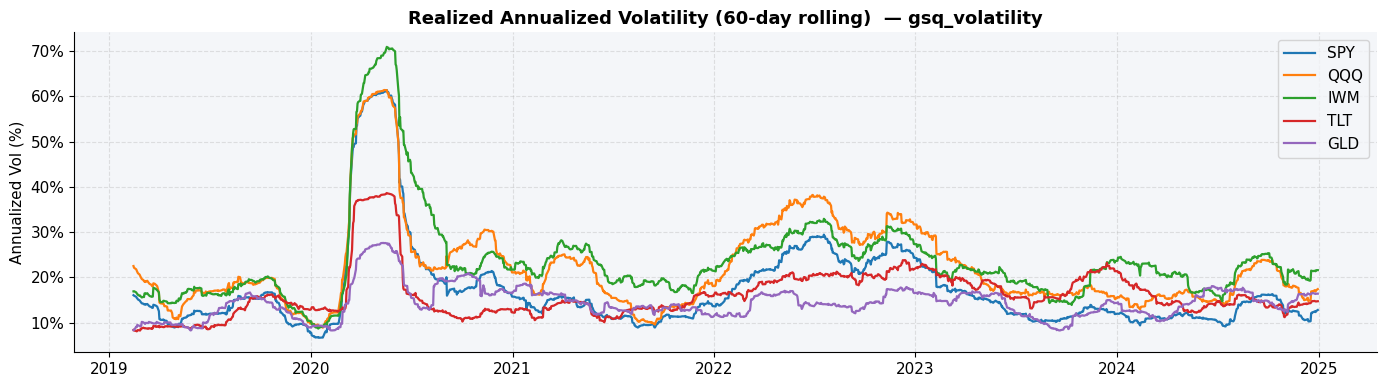

In [46]:
# ── Realized Volatility Over Time ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
for i, sym in enumerate(UNIVERSE):
    rv = gsq_volatility(close[sym], 60)
    ax.plot(rv.index, rv.values, label=sym, color=PALETTE[i], linewidth=1.6)
ax.set_title('Realized Annualized Volatility (60-day rolling)  — gsq_volatility',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
plt.tight_layout(); plt.show()

## 12. Live Paper Trading — Alpaca

The `gs_quant.alpaca` package handles all broker connectivity. Set these environment variables before running this section:

```bash
export ALPACA_API_KEY_ID="PK..."
export ALPACA_SECRET_KEY="..."
```

The cell auto-detects whether keys are present and prints a demo output if not.

In [47]:
import datetime as dt

def _demo_output():
    print('[DEMO MODE]  Alpaca keys not found — set ALPACA_API_KEY_ID & ALPACA_SECRET_KEY')
    print('\nSignals that would be sent to broker right now:')
    print('-' * 56)
    print(signals[['latest_price','momentum','eligible','target_wt']].to_string())
    print('\nVol-Targeted weights:')
    for sym, w in vt_w.items():
        print(f'  {sym:<5}  {w*100:.1f}%')

try:
    config = AlpacaConfig.from_env(paper=True)
    broker = build_alpaca_broker(config)

    account   = broker.get_account()
    positions = broker.list_positions()

    print('══ Alpaca Paper Account ══════════════════════════════════')
    print(f'  Equity      : ${account.equity:>12,.2f}')
    print(f'  Cash        : ${account.cash:>12,.2f}')
    print(f'  Buying Power: ${account.buying_power:>12,.2f}')
    print(f'  Blocked     : {account.account_blocked or account.trading_blocked}')

    if positions:
        print('\n══ Current Positions ════════════════════════════════════')
        pos_df = pd.DataFrame([
            {'Symbol': sym, 'Quantity': pos.quantity,
             'Market Value': pos.market_value, 'Price': pos.current_price}
            for sym, pos in positions.items()
        ])
        print(pos_df.to_string(index=False))

    print('\n══ Rebalance Plan (Dry Run) ══════════════════════════════')
    plan = run_rebalance(broker, SETTINGS, dry_run=True)
    print(format_plan(plan))

except ValueError:
    _demo_output()

[DEMO MODE]  Alpaca keys not found — set ALPACA_API_KEY_ID & ALPACA_SECRET_KEY

Signals that would be sent to broker right now:
--------------------------------------------------------
        latest_price  momentum  eligible  target_wt
symbol                                             
QQQ       512.362122  0.058130      True       50.0
SPY       579.809143  0.028653     False        0.0
IWM       217.838364  0.002015     False        0.0
TLT        82.498619 -0.092431     False        0.0
GLD       240.630005 -0.009998     False        0.0

Vol-Targeted weights:
  QQQ    57.4%


In [48]:
# ── EXECUTE ORDERS — uncomment only after reviewing the dry-run above ─────────
# config     = AlpacaConfig.from_env(paper=True)
# broker     = build_alpaca_broker(config)
# live_plan  = run_rebalance(broker, SETTINGS, dry_run=False)
# print(format_plan(live_plan))

print('Execution cell ready.  Uncomment to submit market orders to the paper account.')

Execution cell ready.  Uncomment to submit market orders to the paper account.
